## Variational Quantum Eigensolver (VQE) for HeH+ Ion

### Description

This Jupyter notebook implements the Variational Quantum Eigensolver (VQE) algorithm to estimate the ground state energy of the HeH+ ion using quantum computing. The implementation uses PennyLane, a quantum machine learning library, to perform quantum chemistry calculations.

The notebook constructs the molecular Hamiltonian for HeH+ with a bond length of approximately 1.46 Å, and uses a simple ansatz consisting of an initial basis state preparation and a double excitation gate to optimize the energy.

In [56]:
%pip install pennylane matplotlib

  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.1 MB ? eta -:--:--
   --- ------------------------------------ 0.8/8.1 MB 2.8 MB/s eta 0:00:03
   ---------- ----------------------------- 2.1/8.1 MB 4.5 MB/s eta 0:00:02
   --------------------- ------------------ 4.5/8.1 MB 6.5 MB/s eta 0:00:01
   ---------------------------------------- 8.1/8.1 MB 10.1 MB/s  0:00:00
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ---------------------------------------- 0.0/2.3 MB ? eta -:--:--
   ---------------------------------------- 2.3/2.3 MB 10.3 MB/s  0:00:00
   ---------------------------------------- 0.0/7.1 MB ? eta -:--:--
   ------------------------------- -------- 5.5/7.1 MB 27.9 MB/s eta 0:00:01
   ---------------------------------------- 7.1/7.1 MB 27.3 MB/s  0:00:00
Using cached p

In [1]:
import pennylane as qml
from pennylane import numpy as np
import matplotlib.pyplot as plt

In [4]:
symbols = ["He", "H"]

geometry = np.array([[0.0, 0.0, 0.0], [0.0, 0.0, 1.4626278]], requires_grad=False) 

H, qubits = qml.qchem.molecular_hamiltonian(symbols, geometry, charge=1)


In [5]:
print(f"Number of qubits required: {qubits}")

Number of qubits required: 4


In [6]:
dev = qml.device("default.qubit", wires=qubits)

In [7]:
@qml.qnode(dev)
def ansatz(params):
    qml.BasisState(np.array([1, 1, 0, 0]), wires=range(qubits))
    qml.DoubleExcitation(params[0], wires=range(qubits))
    return qml.expval(H)

In [9]:
opt = qml.GradientDescentOptimizer(stepsize=0.4)
theta = np.array([0.0], requires_grad=True)

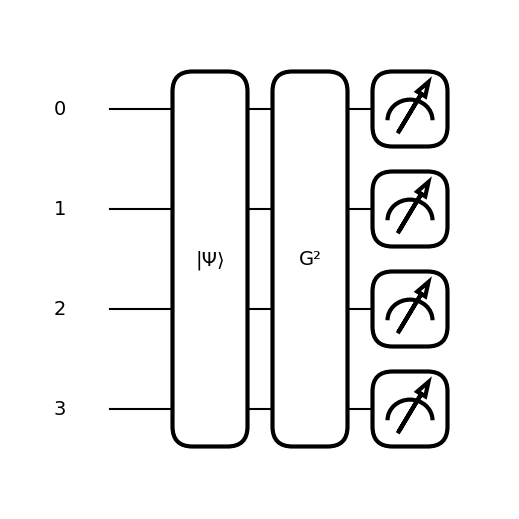

In [10]:
fig, ax = qml.draw_mpl(ansatz)(theta)
plt.show()

In [53]:
energy = [ansatz(theta)]

In [54]:
max_iterations = 40
convergence_tol = 1e-8

In [55]:
print("\nStarting VQE Optimization...")

for n in range(max_iterations):
    theta, prev_energy = opt.step_and_cost(ansatz, theta)
    energy.append(ansatz(theta))
    conv = np.abs(energy[-1] - prev_energy)
    if n % 2 == 0 :
     print(f"Iteration = {n}, Energy = {energy[-1]:.8f} Ha, Convergence = {conv:.8f}")
    if conv <= convergence_tol:
        break

print(f"\nVQE Optimization completed in {n} iterations.")
print(f"Final VQE Energy: {energy[-1]:.8f} Ha")
print(f"Optimal theta: {theta.item():.4f} radians")


Starting VQE Optimization...
Iteration = 0, Energy = -2.84831527 Ha, Convergence = 0.00653813
Iteration = 2, Energy = -2.85083019 Ha, Convergence = 0.00057356
Iteration = 4, Energy = -2.85104928 Ha, Convergence = 0.00004989
Iteration = 6, Energy = -2.85106833 Ha, Convergence = 0.00000434
Iteration = 8, Energy = -2.85106999 Ha, Convergence = 0.00000038
Iteration = 10, Energy = -2.85107013 Ha, Convergence = 0.00000003

VQE Optimization completed in 11 iterations.
Final VQE Energy: -2.85107014 Ha
Optimal theta: 0.1275 radians
